In [6]:
# =============================================================================
# South American LLJ Detection  —  v2
# Methodology: Wang & Fu (2004), J. Climate 17:1247-1262
#
# Data: MRI-ESM2-0, 6hrPlev (6-hourly on pressure levels)
#       historical (1850–2014) + ssp585 (2015–2100)
#
# Infrastructure: your filecache + combined_preprocessing
# Detection logic: area-weighted index, monthly percentile threshold,
#                  contiguous episode finder
# =============================================================================

import warnings
import numpy as np
import pandas as pd
import xarray as xr
import intake
import fsspec
import dask
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm
from xmip.preprocessing import combined_preprocessing

# ── Dask ──────────────────────────────────────────────────────────────────────
# On HPCC with 50 cores:
#   from dask.distributed import Client
#   client = Client(n_workers=50, threads_per_worker=1, memory_limit='1GB')
# Locally, keep synchronous:
dask.config.set(scheduler="synchronous")

# =============================================================================
# 1.  CATALOG + QUERY
# =============================================================================

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    col = intake.open_esm_datastore(
        "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    )

In [7]:
# ── table_id selection (confirmed by catalog_diagnostic.py) ──────────────────
# 6hrLev    : archived for MRI-ESM2-0 but on model (hybrid sigma) levels —
#             no direct 850 hPa selection; requires ps + hybrid coefficients
# 6hrPlev   : NOT archived for MRI-ESM2-0 in Pangeo (0 entries)
# 6hrPlevPt : NOT archived for MRI-ESM2-0 in Pangeo (0 entries)
# day       : archived, pressure levels, historical r1-r5 + ssp585 r1  ✓
# Amon      : archived but monthly — too coarse for MJO work
#
# Note: ssp585 only has r1i1p1f1 in 'day'. For multi-member future ensembles
# you would need to drop to 'Amon'. Fine for now.

query = dict(
    source_id='MRI-ESM2-0',
    table_id='day',                # ← confirmed available by diagnostic
    experiment_id=['historical', 'ssp585'],
    variable_id=['va', 'ua'],      # meridional + zonal wind at pressure levels
    member_id='r1i1p1f1',
)

cat = col.search(**query)
print("Entries found:")
print(cat.df[["source_id", "table_id", "experiment_id",
              "variable_id", "member_id"]].drop_duplicates().to_string())

Entries found:
    source_id table_id experiment_id variable_id member_id
0  MRI-ESM2-0      day    historical          ua  r1i1p1f1
1  MRI-ESM2-0      day    historical          va  r1i1p1f1
2  MRI-ESM2-0      day        ssp585          ua  r1i1p1f1
3  MRI-ESM2-0      day        ssp585          va  r1i1p1f1


In [14]:
# =============================================================================
# 2.  LOAD WITH FILECACHE
# =============================================================================

cache_path = '/scratch/fld1/cmip_cache'

storage_options = {
    'filecache': {
        'cache_storage': cache_path,
        'target_protocol': 'gs',
    }
}

z_kwargs = {'consolidated': True, 'decode_times': True}
warnings.filterwarnings("ignore")

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    dset_dict = cat.to_dataset_dict(
        zarr_kwargs=z_kwargs,
        storage_options=storage_options,
        preprocessing=combined_preprocessing,
    )

print("\nLoaded dataset keys:")
for k in dset_dict.keys():
    print(" ", k)

# =============================================================================
# 3.  SELECT DATA
# =============================================================================
# ── CORRECTED time logic ──────────────────────────────────────────────────────
# Historical ends 2014; ssp585 starts 2015.
# Selecting '2060' from historical returns EMPTY data — no error, just nothing.
# Use the correct dataset for each period.
#
# For local testing: use a single year of historical.
# For HPCC:         concatenate both runs (see concat block below).

# Identify keys (combined_preprocessing may rename them)
hist_key = [k for k in dset_dict if 'historical' in k and 'va' in k or
            all(x in k for x in ['historical', 'MRI-ESM2-0'])][0]
ssp_key  = [k for k in dset_dict if 'ssp585'    in k][0]

print(f"\nUsing historical key : {hist_key}")
print(f"Using ssp585 key     : {ssp_key}")

# ── Spatial domain (Wang & Fu LLJ region) ────────────────────────────────────
# 15–25°S, 55–65°W
# combined_preprocessing standardises lon to −180→180, so use negative values.
LAT_S, LAT_N = -25.0, -15.0
LON_W, LON_E = 295.0, 305.0

# ── Local Mac test: 1 year of historical ─────────────────────────────────────
TEST_YEAR = '1995'

ds_hist_full = dset_dict[hist_key]
ds_test = (
    ds_hist_full
    .sel(time=slice(TEST_YEAR, TEST_YEAR),
         lat=slice(LAT_S, LAT_N),
         lon=slice(LON_W, LON_E))
)


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'



Loaded dataset keys:
  CMIP.MRI.MRI-ESM2-0.historical.day.gn
  ScenarioMIP.MRI.MRI-ESM2-0.ssp585.day.gn

Using historical key : CMIP.MRI.MRI-ESM2-0.historical.day.gn
Using ssp585 key     : ScenarioMIP.MRI.MRI-ESM2-0.ssp585.day.gn


In [15]:
# ── HPCC full run: uncomment to concatenate historical + ssp585 ──────────────
# ds_ssp_full = dset_dict[ssp_key]
# ds_full = xr.concat(
#     [ds_hist_full, ds_ssp_full],
#     dim='time',
#     data_vars='minimal',   # avoids duplicating static fields
#     coords='minimal',
#     compat='override',
# ).sel(lat=slice(LAT_S, LAT_N), lon=slice(LON_W, LON_E))

# =============================================================================
# 4.  EXTRACT 850 hPa MERIDIONAL WIND
# =============================================================================

# combined_preprocessing standardises the pressure coordinate to 'plev' in Pa.
print("\nAvailable pressure levels (Pa):", ds_test['plev'].values)

PLEV_850 = 85000.0   # Pa — if levels are in hPa, use 850.0
va_850 = ds_test['va'].sel(plev=PLEV_850, method='nearest')

print(f"Nearest plev selected: {float(va_850.plev.values):.0f} Pa")
print(f"Data shape (time, lat, lon): {va_850.shape}")

# Load small domain into memory
va_850 = va_850.load()


Available pressure levels (Pa): [100000.  85000.  70000.  50000.  25000.  10000.   5000.   1000.]
Nearest plev selected: 85000 Pa
Data shape (time, lat, lon): (1, 1, 365, 9, 9)


In [16]:
# =============================================================================
# 5.  LLJ INDEX  (area-weighted mean)
# =============================================================================

weights   = np.cos(np.deg2rad(va_850.lat)).broadcast_like(va_850.isel(time=0))
llj_xr    = va_850.weighted(weights).mean(dim=['lat', 'lon'])

# Strip extra coordinates added by combined_preprocessing (member_id, 
# source_id, etc.) before converting to Series, otherwise .to_series()
# produces a MultiIndex and .index.month fails
llj_daily = (
    llj_xr
    .reset_coords(drop=True)  # drop non-dimension coordinates
    .squeeze()                # drop any size-1 dimensions
    .to_series()
)
llj_daily.index = pd.DatetimeIndex(llj_daily.index)  # ensure plain DatetimeIndex
llj_daily.name = 'llj_index_ms'
llj_daily.name = 'llj_index_ms'

# Data is already daily — no resampling needed.
# If you switch to 6hrLev/6hrPlev later, add:
#   llj_daily = llj_daily.resample('1D').mean()

print(f"\nLLJ index stats ({TEST_YEAR}):")
print(llj_daily.describe().round(3))

seasonal_means = llj_daily.groupby(llj_daily.index.month).mean()
print("\nMonthly mean LLJ index (m/s)  — JJA should be most negative:")
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
for m, v in seasonal_means.items():
    print(f"  {month_labels[m]}: {v:+.2f}")


LLJ index stats (1995):
count    365.000
mean      -3.021
std        4.812
min      -14.390
25%       -6.553
50%       -3.214
75%       -0.098
max       11.233
Name: llj_index_ms, dtype: float64

Monthly mean LLJ index (m/s)  — JJA should be most negative:
  Jan: -3.24
  Feb: -2.39
  Mar: -4.30
  Apr: -2.09
  May: -3.08
  Jun: -1.89
  Jul: -5.03
  Aug: -4.85
  Sep: -0.88
  Oct: -2.90
  Nov: -2.24
  Dec: -3.14


In [17]:
# =============================================================================
# 6.  ACTIVE LLJ DETECTION  (monthly 20th-percentile threshold)
# =============================================================================
# Using monthly thresholds controls for the strong seasonal cycle —
# critical for MJO compositing, which spans all calendar months.

monthly_thresh = llj_daily.groupby(llj_daily.index.month).quantile(0.20)

def flag_active_monthly(series, thresholds):
    flags = pd.Series(False, index=series.index)
    for month, thresh in thresholds.items():
        mask = series.index.month == month
        flags[mask] = series[mask] <= thresh
    return flags

active_flags = flag_active_monthly(llj_daily, monthly_thresh)

llj_df = pd.DataFrame({
    'llj_index':      llj_daily,
    'active_monthly': active_flags,
})
llj_df.index.name = 'time'

In [18]:
# =============================================================================
# 7.  CONTIGUOUS EPISODE FINDER
# =============================================================================

def find_episodes(active_flags, llj_series, min_duration=1):
    """
    Find contiguous blocks of active LLJ days.

    Returns a DataFrame with start, end, duration, peak_date, peak_value.
    peak_date is useful as the anchor for MJO-phase lookup later.
    """
    episodes = []
    in_ep    = False

    for date, active in active_flags.items():
        if active and not in_ep:
            in_ep = True
            start = date
        elif not active and in_ep:
            in_ep = False
            end = date - pd.Timedelta(days=1)
            dur = (end - start).days + 1
            if dur >= min_duration:
                window = llj_series.loc[start:end]
                episodes.append({
                    'start':      start,
                    'end':        end,
                    'duration':   dur,
                    'peak_date':  window.idxmin(),
                    'peak_value': window.min(),
                })

    if in_ep:   # episode running to end of data
        end = active_flags.index[-1]
        dur = (end - start).days + 1
        if dur >= min_duration:
            window = llj_series.loc[start:end]
            episodes.append({
                'start': start, 'end': end, 'duration': dur,
                'peak_date': window.idxmin(), 'peak_value': window.min(),
            })

    return pd.DataFrame(episodes)

episodes = find_episodes(active_flags, llj_daily, min_duration=1)
print(f"\nActive LLJ episodes detected: {len(episodes)}")
print(episodes.to_string(index=False))

# =============================================================================
# 8.  SAVE
# =============================================================================

llj_df.to_csv('sallj_index.csv')
episodes.to_csv('sallj_episodes.csv', index=False)
print("\nSaved: sallj_index.csv, sallj_episodes.csv")


Active LLJ episodes detected: 47
              start                 end  duration           peak_date  peak_value
1995-01-06 12:00:00 1995-01-07 12:00:00         2 1995-01-06 12:00:00   -6.077853
1995-01-12 12:00:00 1995-01-12 12:00:00         1 1995-01-12 12:00:00   -6.429564
1995-01-15 12:00:00 1995-01-15 12:00:00         1 1995-01-15 12:00:00   -7.196215
1995-01-24 12:00:00 1995-01-24 12:00:00         1 1995-01-24 12:00:00   -7.050608
1995-01-28 12:00:00 1995-01-29 12:00:00         2 1995-01-29 12:00:00   -8.242157
1995-02-06 12:00:00 1995-02-06 12:00:00         1 1995-02-06 12:00:00   -7.417771
1995-02-09 12:00:00 1995-02-09 12:00:00         1 1995-02-09 12:00:00   -6.782331
1995-02-21 12:00:00 1995-02-24 12:00:00         4 1995-02-22 12:00:00   -6.800373
1995-03-06 12:00:00 1995-03-08 12:00:00         3 1995-03-07 12:00:00   -8.625899
1995-03-20 12:00:00 1995-03-21 12:00:00         2 1995-03-21 12:00:00  -11.969480
1995-03-30 12:00:00 1995-03-31 12:00:00         2 1995-03-30 12:

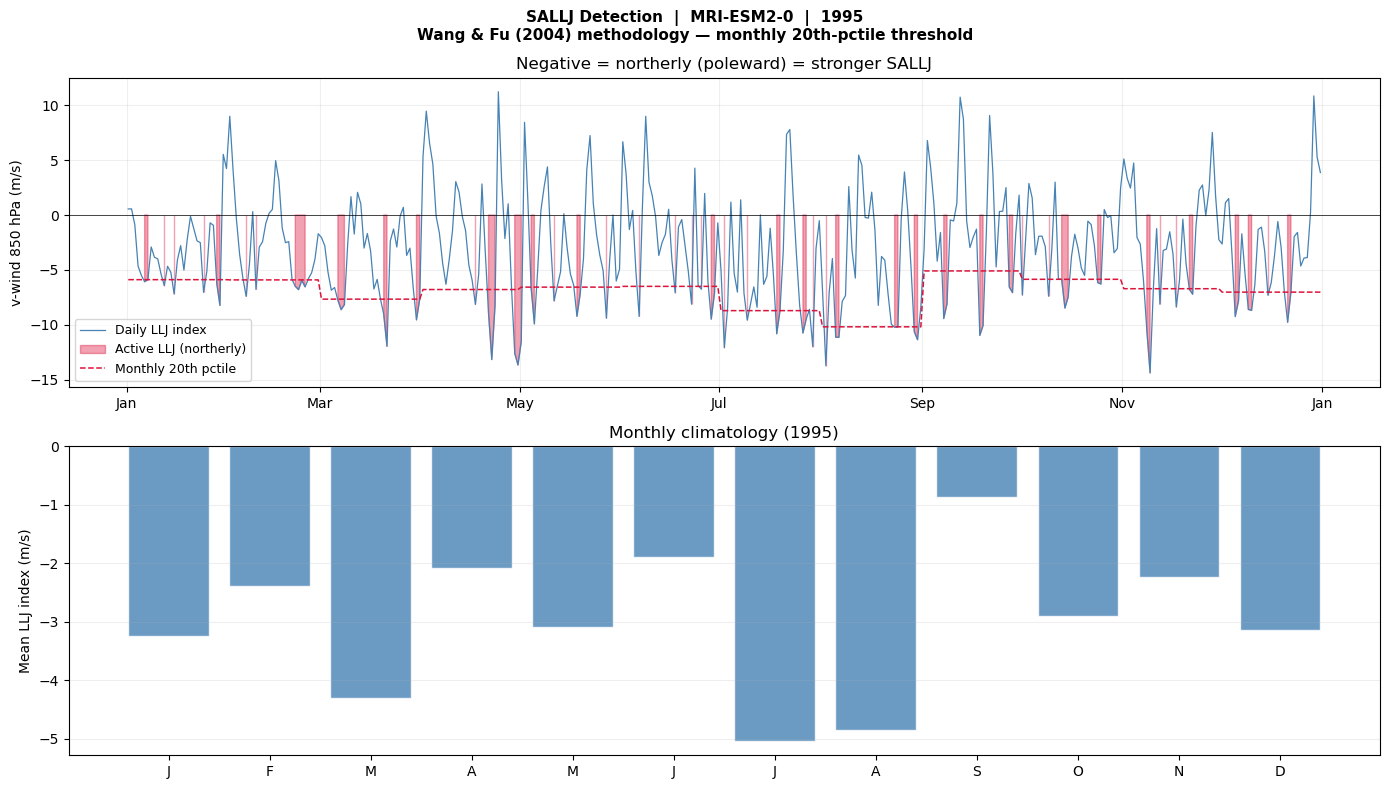

In [19]:
# =============================================================================
# 9.  QUICK PLOT
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    f'SALLJ Detection  |  MRI-ESM2-0  |  {TEST_YEAR}\n'
    'Wang & Fu (2004) methodology — monthly 20th-pctile threshold',
    fontsize=11, fontweight='bold'
)

ax1 = axes[0]
t20 = pd.Series(
    [monthly_thresh[d.month] for d in llj_daily.index],
    index=llj_daily.index
)
ax1.plot(llj_daily.index, llj_daily.values, lw=0.9,
          color='steelblue', label='Daily LLJ index')
ax1.fill_between(llj_daily.index, llj_daily.values, 0,
                  where=active_flags, alpha=0.4, color='crimson',
                  label='Active LLJ (northerly)')
ax1.plot(t20.index, t20.values, color='crimson', lw=1.1,
          ls='--', label='Monthly 20th pctile')
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel('v-wind 850 hPa (m/s)')
ax1.set_title('Negative = northerly (poleward) = stronger SALLJ')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.grid(alpha=0.2)

ax2 = axes[1]
clim = llj_daily.groupby(llj_daily.index.month).mean()
ax2.bar(range(1, 13), clim.values, color='steelblue', alpha=0.8,
         edgecolor='white')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.axhline(0, color='k', lw=0.5)
ax2.set_ylabel('Mean LLJ index (m/s)')
ax2.set_title(f'Monthly climatology ({TEST_YEAR})')
ax2.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('sallj_detection_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# NOTE: If 6hrPlev is unavailable and you must use 6hrLev
# =============================================================================
# Model-level → pressure-level interpolation requires:
#   1. Add 'ps' (surface pressure) and 'hus' (specific humidity) to query
#   2. Read hybrid-sigma coefficients from the dataset (a_bnds, b_bnds attrs)
#   3. Use metpy.interpolate_1d or xgcm to regrid to 85000 Pa
# This is roughly 40 extra lines and ~3x slower. Only do it if 6hrPlev
# is genuinely missing from the catalog for your model.
# =============================================================================

# =============================================================================
# NEXT STEP: MJO COMPOSITING
# =============================================================================
# 1. Download Wheeler-Hendon RMM index:
#    http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt
#
# 2. Load and merge:
#    rmm = pd.read_csv('rmm.txt', ..., index_col='date', parse_dates=True)
#    merged = llj_df.join(rmm[['phase', 'amplitude']], how='inner')
#    merged = merged[merged['amplitude'] > 1.0]  # active MJO only
#
# 3. Composite:
#    composites = merged.groupby('phase')['llj_index'].agg(['mean','std','count'])
#    # Then test significance vs. shuffled phase labels (bootstrap)
# =============================================================================